# Vietnam — Full Piotroski F-Score Study

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances, plus a dollar-neutral
long-short book (long top-k scores, short bottom-k) where shorting is
available → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** Statements come from the team's own preprocessing repository (`../thesis`), which crawls FireAnt, CafeF and TCBS into `fscore.db`, reconciles the three, applies accounting checks and writes a per-firm-year panel — FY2009 onward, the span the Vietnamese sources cover. `scripts/build_vietnam_data.py` maps that panel into this study's canonical schema. `report_date` is the 31 December fiscal year end (the panel carries no filing date), and the reporting lag is **6 months**: 31 December + 6 months = 30 June, the last day before a 1 July formation. That is the most conservative rule that still admits the prior fiscal year, and it is the same screening date the sibling pipeline uses, so both branches select on the same information. Formations run **July 2012 .. July 2024** — thirteen chained holding years, the same calendar as the US and Japan. The price cache reaches August 2026 and would support a July 2025 formation, but taking it would move the goalposts relative to the other two markets. Survivorship is **partial rather than total**: the price panel does retain lines that died inside the sample — 125 of its 1,371 tickers print for the last time before 2026, spread across 2012-2025 — but names the vendor no longer resolves at all leave no trace to count, so the residual is unquantified. Covariances are estimated on 36 months of daily returns ending the day before formation.

Run `python scripts/build_vietnam_data.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.plotting import setup_plots, save_fig
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)
from fscore.evaluation import local_ff3_factors

setup_plots()      # study-wide figure defaults; every saved chart is 300 dpi
RESULTS_FIG = ROOT / "results" / "figures"
MARKET = "vietnam"
YEARS = list(range(2012, 2025))
LAG_MONTHS = 6  # report_date = 31 Dec fiscal year end; +6m = 30 Jun, the day before formation
END_CAP = None   # every holding year is complete; nothing is truncated
fund, prices, sectors, bench = load_cached(MARKET, ROOT / "data")
membership = None
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 1814 tickers, FY2009–FY2025
prices: 1371 tickers, 2009-01-02 → 2026-08-07


fiscal_year
2009     914
2010     973
2011    1047
2012    1103
2013    1196
2014    1325
2015    1456
2016    1568
2017    1598
2018    1635
2019    1640
2020    1621
2021    1574
2022    1516
2023    1476
2024    1453
2025    1398
Name: statements, dtype: int64

### 0. Cross-validation of the signal layer

The Vietnamese nine signals arrive from the team's preprocessing repository
already computed. The US and Japanese ones are computed by
`fscore.signal.piotroski` in this repository. Putting the three markets in one
table is only legitimate if they rest on the same scoring rules, so this
section recomputes every Vietnamese firm-year with *this* repository's signal
code, from the canonical statement lines `scripts/build_vietnam_data.py`
writes, and compares flag by flag against the shipped panel.

Two conventions had to be matched for this to be a real test rather than a
tautology: `net_income` is the parent-company share, and `cogs` is derived as
`net_sales - gross_profit` so that `(revenue - cogs) / revenue` here is the
same quantity as the `gross_profit / net_sales` margin the sibling pipeline
scored. Everything else — beginning-of-year asset scaling on both sides of
every delta, the cash-flow equity-issuance measure, dropping firm-years whose
nine signals are not all computable — is this repository's own rule set.

In [2]:
from fscore.data.fs_clean import score_panel_path
from fscore.signal.piotroski import piotroski_signals

shipped = pd.read_csv(score_panel_path(MARKET, ROOT / "data"))
rows = []
for y in range(int(shipped.score_year.min()), int(shipped.score_year.max()) + 1):
    snap = fund[fund.fiscal_year.isin([y, y - 1, y - 2])]
    scored_y = piotroski_signals(snap, year=y)
    if len(scored_y):
        rows.append(scored_y.assign(score_year=y))
ours = pd.concat(rows, ignore_index=True)

PAIRS = [("roa_pos", "f_roa"), ("cfo_pos", "f_cfo"), ("delta_roa_pos", "f_droa"),
         ("accruals_ok", "f_accrual"), ("delta_leverage_down", "f_dlever"),
         ("delta_liquidity_up", "f_dliquid"), ("no_issuance", "f_eq_offer"),
         ("delta_margin_up", "f_dmargin"), ("delta_turnover_up", "f_dturn")]
both = ours.merge(shipped, on=["ticker", "score_year"], suffixes=("_ours", "_theirs"))
agree = pd.Series({"composite F-Score": (both.fscore_ours == both.fscore_theirs).mean(),
                   **{ours_c: (both[ours_c] == both[theirs_c]).mean()
                      for ours_c, theirs_c in PAIRS}}, name="agreement")
print(f"{len(both):,} of {len(shipped):,} shipped firm-years matched on (ticker, score_year)")
print(f"mean absolute F-Score difference: {(both.fscore_ours - both.fscore_theirs).abs().mean():.4f}")
(100 * agree).round(2).to_frame("% agreement")

9,482 of 9,482 shipped firm-years matched on (ticker, score_year)
mean absolute F-Score difference: 0.0000


,% agreement
composite F-Score,100.0
roa_pos,100.0
cfo_pos,100.0
delta_roa_pos,100.0
accruals_ok,100.0
delta_leverage_down,100.0
delta_liquidity_up,100.0
no_issuance,100.0
delta_margin_up,100.0
delta_turnover_up,100.0


### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

**Data discarded before any test.** A firm-year is scored
only when all nine signals are computable from the fiscal T-1 and T-2
statements; partial scores are dropped rather than summed over whatever is
available (an incomplete score is not a low score). The per-formation count
is `dropped_incomplete_signals` in the diagnostics below.

In [3]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  membership=membership, end_cap=END_CAP, seed=42,
                  detone=False)   # RMT denoise only — detoning is
                                  # out of scope for this study
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,dropped_incomplete_signals,tie_break_slots,cov_est_days,delisted_in_holding_year,k,fscore_mean,fscore_basket_min
year,,,,,,,,,,
2012,150,60,52,280,6,749,2,30,4.326923,4
2013,150,60,56,205,12,746,0,30,4.821429,5
2014,150,60,57,154,12,746,2,30,4.807018,5
2015,150,60,57,195,4,743,0,30,5.508772,5
2016,150,60,51,256,6,746,0,30,5.196078,5
2017,150,60,53,255,6,749,1,30,5.169811,5
2018,150,60,57,228,7,752,1,30,5.298246,5
2019,150,60,58,153,13,748,1,30,5.637931,6
2020,150,60,58,106,5,750,0,30,5.396552,5


### 2. F-Score distribution within the value universe, per formation

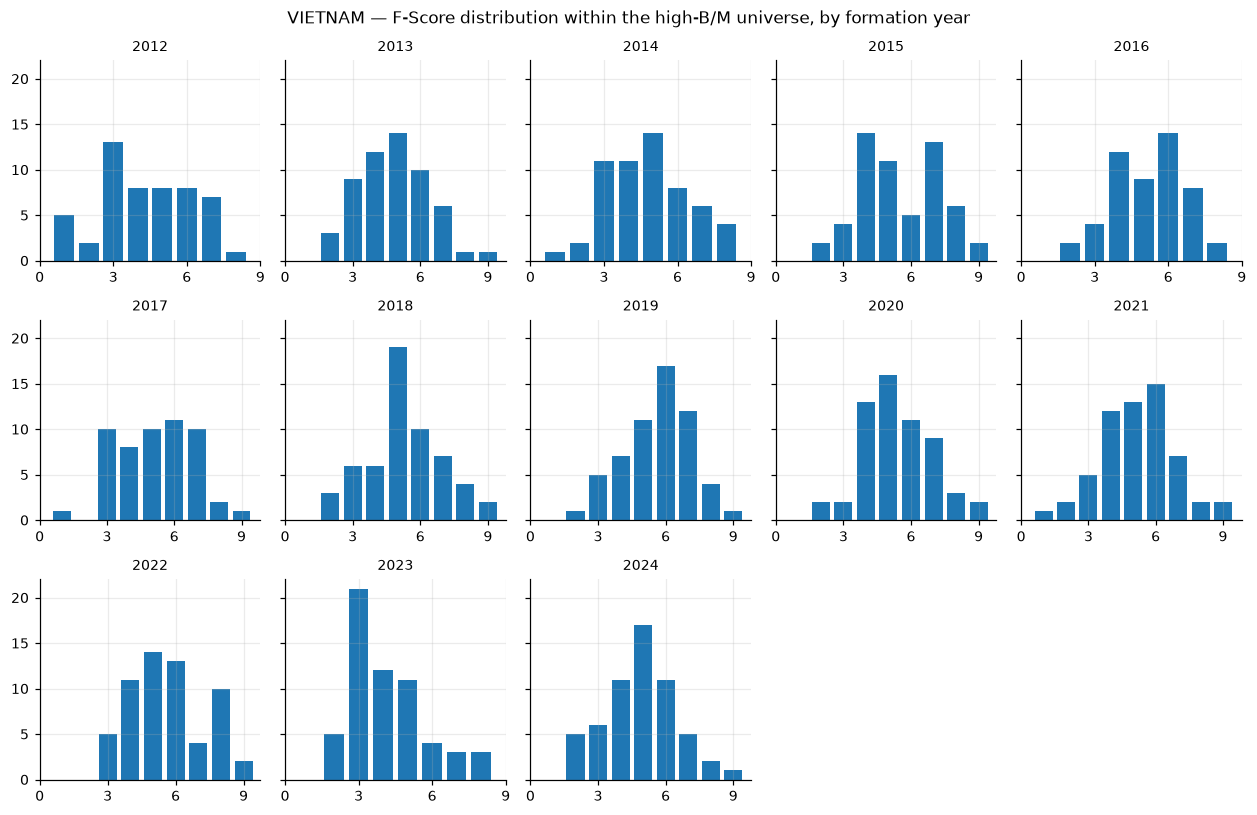

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,52.00,56.00,57.00,57.00,51.00,53.00,57.00,58.00,58.00,59.00,59.00,59.00,58.00
mean,4.33,4.82,4.81,5.51,5.20,5.17,5.30,5.64,5.40,5.19,5.64,4.15,4.88
std,1.88,1.55,1.66,1.77,1.47,1.68,1.68,1.51,1.54,1.64,1.65,1.56,1.59
min,1.00,2.00,1.00,2.00,2.00,1.00,2.00,2.00,2.00,1.00,3.00,2.00,2.00
25%,3.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,4.00,4.00,3.00,4.00
50%,4.00,5.00,5.00,5.00,5.00,5.00,5.00,6.00,5.00,5.00,5.00,4.00,5.00
75%,6.00,6.00,6.00,7.00,6.00,6.00,6.00,7.00,6.00,6.00,7.00,5.00,6.00
max,8.00,9.00,8.00,9.00,8.00,9.00,9.00,9.00,9.00,9.00,9.00,8.00,9.00


In [4]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); save_fig(f"{MARKET}_fscore_distribution", directory=RESULTS_FIG); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

Both indices are VND, like the portfolios — no currency effect enters this row. They are, however, **capital indices**: neither reinvests cash dividends, while the portfolios are built on dividend-adjusted closes. The gap is the index dividend yield, historically around 1.5-2% a year, and it flatters every portfolio against these two rows by that much. No total-return version of either index exists in the source database, so this is disclosed rather than corrected.

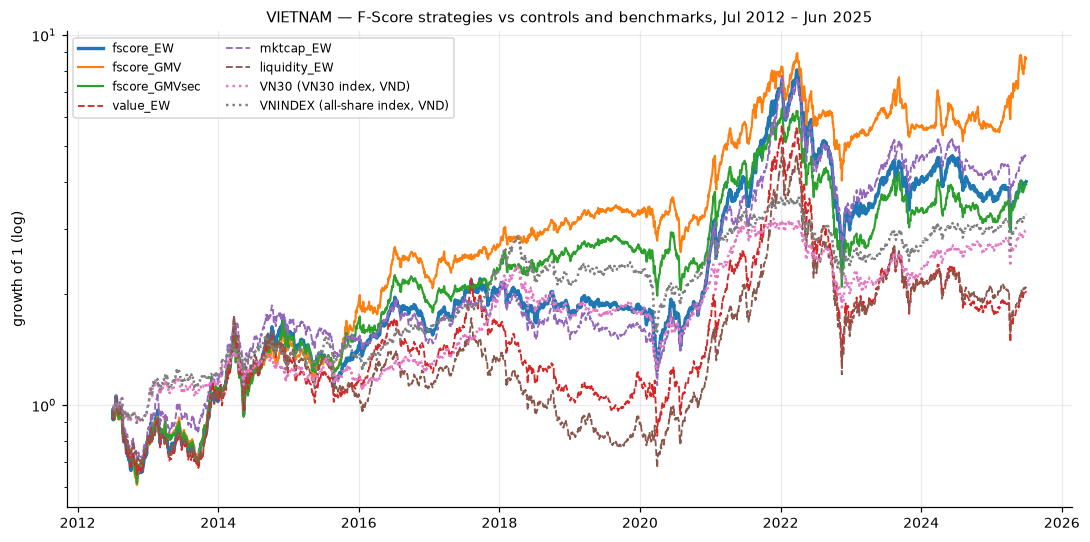

In [5]:
BENCH = {"VN30 (VN30 index, VND)": "VN30",
         "VNINDEX (all-share index, VND)": "VNINDEX"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
# solid for the F-Score variants, dashed for the controls; a strategy not
# named here still plots, so adding one never breaks the figure
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "fscore_LS": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles.get(s, ("-" if s.startswith("fscore") else "-.", 1.2))
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(f"{MARKET}_nav_vs_benchmarks", directory=RESULTS_FIG); plt.show()

In [6]:
tbl = study.summary()      # gross first; costs follow separately
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)   # benchmarks are buy-and-hold: no turnover
tbl[["ann_return", "ann_vol", "sharpe", "max_drawdown",
     "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.114,0.261,0.438,-0.704,30.0,30.000
fscore_GMV,0.183,0.240,0.763,-0.548,30.0,6.972
fscore_GMVsec,0.113,0.241,0.468,-0.670,30.0,8.931
value_EW,0.057,0.281,0.202,-0.770,30.0,30.000
mktcap_EW,0.129,0.259,0.498,-0.682,30.0,30.000
liquidity_EW,0.059,0.270,0.219,-0.756,30.0,30.000
"VN30 (VN30 index, VND)",0.089,0.188,0.474,-0.481,NaN,NaN
"VNINDEX (all-share index, VND)",0.097,0.180,0.537,-0.453,NaN,NaN


`nominal_k` is the basket size, `effective_n` is 1/Σw² —
an optimised or sector-capped book concentrates, so the two are not the same
number of holdings. Turnover and the net-of-cost sensitivity follow below.

In [7]:
tbl[["turnover", "cost_drag",
     "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.6977,0.0028,0.1116,0.4274
fscore_GMV,0.8962,0.0036,0.1795,0.7477
fscore_GMVsec,0.8691,0.0035,0.1094,0.4540
value_EW,0.6147,0.0025,0.0544,0.1936
mktcap_EW,0.5255,0.0021,0.1270,0.4898
liquidity_EW,0.7491,0.0030,0.0560,0.2075
"VN30 (VN30 index, VND)",NaN,NaN,NaN,NaN
"VNINDEX (all-share index, VND)",NaN,NaN,NaN,NaN


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; the p-value is one-sided and judged at the study's
single significance level, **5%** (`significant` column). No 1% or 10% tier
is used, so p = 0.06 counts as not significant.

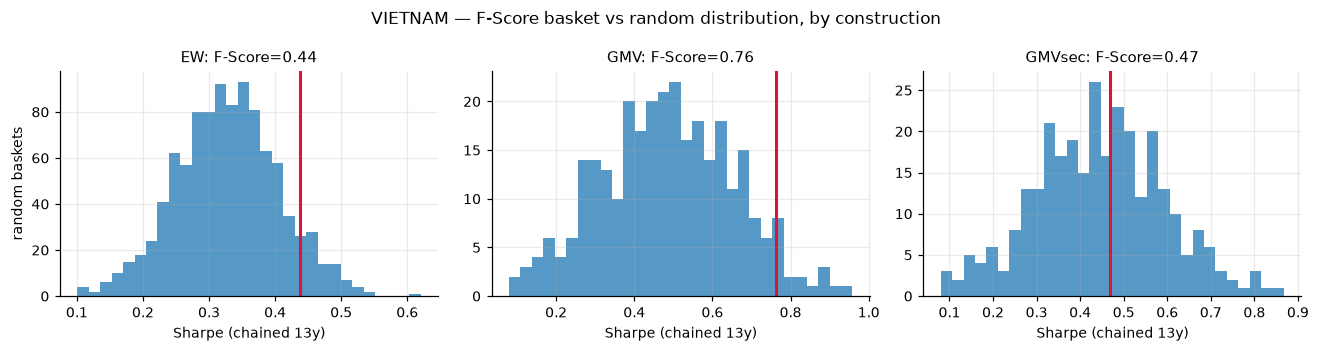

fscore random_mean random_std percentile  \
fscore_EW     ann_return    0.114411    0.086698   0.020379      0.907   
              sharpe        0.438135    0.328209   0.077547      0.915   
              max_drawdown -0.704442   -0.729156   0.018991        0.9   
fscore_GMV    ann_return    0.183061    0.115766   0.040116   0.953333   
              sharpe        0.762599    0.485107   0.170001       0.95   
              max_drawdown -0.547686   -0.651259    0.04827   0.986667   
fscore_GMVsec ann_return    0.112899    0.107819   0.035769       0.55   
              sharpe        0.468419    0.444093   0.149434       0.55   
              max_drawdown -0.670355   -0.683788   0.027636       0.68   

                             p_value significant n_draws  
fscore_EW     ann_return       0.093       False    1000  
              sharpe           0.085       False    1000  
              max_drawdown       0.1       False    1000  
fscore_GMV    ann_return    0.046667        True     300  
              sharpe            0.05       False     300  
              max_drawdown  0.013333        True     300  
fscore_GMVsec ann_return        0.45       False     300  
              sharpe            0.45       False     300  
              max_drawdown      0.32       False     300

In [8]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); save_fig(f"{MARKET}_mc_placement", directory=RESULTS_FIG); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 5. Turnover and implied trading cost

One-way turnover per rebalance, computed on each strategy's actual weights
(so GMV pays for weight drift, not just for name changes); cost drag =
2 x turnover x 20 bp per side, already applied in the `net_*` columns above.
For reference, the random control is redrawn every year and turns over
roughly `1 - k/|universe|`, i.e. in the same range as the F-Score basket.

In [9]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,mean,annual cost drag
fscore_EW,0.640,0.609,0.605,0.815,0.751,0.730,0.649,0.657,0.777,0.724,0.744,0.670,0.698,0.0028
fscore_GMV,0.894,0.906,0.623,1.000,0.920,0.847,0.776,0.853,0.958,1.000,0.976,1.000,0.896,0.0036
fscore_GMVsec,0.899,0.832,0.600,0.979,0.905,0.907,0.719,0.860,0.905,0.965,0.936,0.921,0.869,0.0035
value_EW,0.703,0.596,0.701,0.796,0.710,0.634,0.566,0.476,0.529,0.552,0.587,0.527,0.615,0.0025
mktcap_EW,0.464,0.461,0.476,0.781,0.553,0.488,0.503,0.528,0.439,0.586,0.571,0.456,0.525,0.0021
liquidity_EW,0.798,0.584,0.811,0.900,0.774,0.818,0.665,0.823,0.689,0.769,0.747,0.610,0.749,0.0030


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on three factors (market, size, value) with
Newey-West standard errors. The `alpha_significant` column is the verdict at
the study's single level, 5%.

**The factors are local, not Ken French's.** The library covers the US, Japan
and the developed regions; it does not cover Vietnam, and no free substitute
does. Skipping the regression would leave the study's only emerging market
without the one test that strips style exposure out of the result, so the
factors are built here from the same point-in-time panel the study already
uses — a 2x3 size / book-to-market sort, formed 1 July on fiscal T-1
statements, value-weighted and held for twelve months
(`fscore.evaluation.local_ff3_factors`). Two consequences: the market leg is
this panel's eligible universe rather than the whole exchange, and market cap
is measured at the fiscal year end rather than at formation. The alphas below
are therefore alphas against a *local approximation* of the three factors,
and are not comparable coefficient-for-coefficient with the US and Japan
tables above.

In [10]:
ff = local_ff3_factors(fund, prices, YEARS, lag_months=LAG_MONTHS)
series = {s: study.daily[s].dropna()
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,alpha_significant,alpha,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,-0.000232,-0.058503,-1.691687,0.090706,False,0.05,1.150945,0.086215,0.896636,0.796802,3235
fscore_GMV,0.00011,0.027614,0.507733,0.611641,False,0.05,1.005237,0.277215,0.643559,0.503202,3235
value_EW,-0.000513,-0.129156,-3.126542,0.001769,True,0.05,1.177908,0.267053,1.224151,0.780142,3235


In [11]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to /Users/lap14821-local/Documents/Software Development/worldquant_uni/fscore_capstone/results


### 7. Reading the results

*(filled in after execution)*